<a href="https://colab.research.google.com/github/hzhoujoy/ST554_HW6/blob/main/HW6_part_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ST554_HomeWork_6   
Author: Huiping Zhou   
Date: 3/6/2026

# Part I-More Practice Querying a Database

We will continue working with the [lahman_1871-2022.sqlite](https://github.com/jknecht/baseball-archive-sqlite/releases/tag/2022) database, which contains information on Major League Baseball.

## Question 1
We will connect to the database and then look at all of the tables in the database by using `read_sql()` from pandas and returns it as a dataframe.

In [1]:
import sqlite3
import pandas as pd
# make the connection to the database
con = sqlite3.connect("lahman_1871-2022.sqlite")
#SQL query to return all table names in the data base
pd.read_sql("SELECT * FROM sqlite_master WHERE type='table';", con)

,type,name,tbl_name,rootpage,sql
0,table,AllstarFull,AllstarFull,2,"CREATE TABLE AllstarFull (\nplayerID TEXT,\nye..."
1,table,Appearances,Appearances,3,"CREATE TABLE Appearances (\nyearID INTEGER,\nt..."
2,table,AwardsManagers,AwardsManagers,4,"CREATE TABLE AwardsManagers (\nplayerID TEXT,\..."
3,table,AwardsPlayers,AwardsPlayers,5,"CREATE TABLE AwardsPlayers (\nplayerID TEXT,\n..."
4,table,AwardsShareManagers,AwardsShareManagers,6,CREATE TABLE AwardsShareManagers (\nawardID TE...
5,table,AwardsSharePlayers,AwardsSharePlayers,7,CREATE TABLE AwardsSharePlayers (\nawardID TEX...
6,table,Batting,Batting,8,"CREATE TABLE Batting (\nplayerID TEXT,\nyearID..."
7,table,BattingPost,BattingPost,9,"CREATE TABLE BattingPost (\nyearID INTEGER,\nr..."
8,table,CollegePlaying,CollegePlaying,10,"CREATE TABLE CollegePlaying (\nplayerID TEXT,\..."
9,table,Fielding,Fielding,11,"CREATE TABLE Fielding (\nplayerID TEXT,\nyearI..."


The lahman_1871-2022 database includes 27 tables.

## Question 2
Using SQL, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the playerID and their total (sum) for GS, G, W, L, IPOuts, CG, SHO, and SV columns.

First of all, let us check a few rows of several tables

In [2]:
#check few rows of table Pitching
pd.read_sql('SELECT * FROM Pitching LIMIT 5;',con)

,playerID,yearID,stint,teamID,lgID,W,L,G,GS,CG,...,IBB,WP,HBP,BK,BFP,GF,R,SH,SF,GIDP
0,aardsda01,2004,1,SFN,NL,1,0,11,0,0,...,0,0,2,0,61,5,8,0,1,1
1,aardsda01,2006,1,CHN,NL,3,0,45,0,0,...,0,1,1,0,225,9,25,1,3,2
2,aardsda01,2007,1,CHA,AL,2,1,25,0,0,...,3,2,1,0,151,7,24,2,1,1
3,aardsda01,2008,1,BOS,AL,4,2,47,0,0,...,2,3,5,0,228,7,32,3,2,4
4,aardsda01,2009,1,SEA,AL,3,6,73,0,0,...,3,2,0,0,296,53,23,2,1,2


In [3]:
#check a few rows of table PitchingPost
pd.read_sql('SELECT * FROM PitchingPost LIMIT 5;',con)

,playerID,yearID,round,teamID,lgID,W,L,G,GS,CG,...,IBB,WP,HBP,BK,BFP,GF,R,SH,SF,GIDP
0,aasedo01,1979,ALCS,CAL,AL,1,0,2,0,0,...,1,0,0,0,20,2,1,0,1,0
1,abadfe01,2014,ALWC,OAK,AL,0,0,1,0,0,...,0,0,0,0,1,0,0,0,0,0
2,abbotgl01,1975,ALCS,OAK,AL,0,0,1,0,0,...,0,0,0,0,3,1,0,0,0,0
3,abbotpa01,2000,ALCS,SEA,AL,0,1,1,1,0,...,0,0,0,0,21,0,3,0,0,0
4,abbotpa01,2000,ALDS2,SEA,AL,1,0,1,1,0,...,0,0,1,0,25,0,2,0,1,1


In [4]:
#check few rows of table Batting
pd.read_sql('SELECT * FROM Batting LIMIT 5;',con)

,playerID,yearID,stint,teamID,lgID,G,G_batting,AB,R,H,...,SB,CS,BB,SO,IBB,HBP,SH,SF,GIDP,G_old
0,aardsda01,2004,1,SFN,NL,11,None,0,0,0,...,0,0,0,0,0,0,0,0,0,None
1,aardsda01,2006,1,CHN,NL,45,None,2,0,0,...,0,0,0,0,0,0,1,0,0,None
2,aardsda01,2007,1,CHA,AL,25,None,0,0,0,...,0,0,0,0,0,0,0,0,0,None
3,aardsda01,2008,1,BOS,AL,47,None,1,0,0,...,0,0,0,1,0,0,0,0,0,None
4,aardsda01,2009,1,SEA,AL,73,None,0,0,0,...,0,0,0,0,0,0,0,0,0,None


In [5]:
# check few rows of table HallOfFame
pd.read_sql('SELECT * FROM HallOfFame LIMIT 5;',con)

,playerID,yearid,votedBy,ballots,needed,votes,inducted,category,needed_note
0,aaronha01,1982,BBWAA,415,312,406,Y,Player,None
1,abbotji01,2005,BBWAA,516,387,13,N,Player,None
2,abreubo01,2020,BBWAA,397,298,22,N,Player,None
3,abreubo01,2021,BBWAA,401,301,35,N,Player,None
4,abreubo01,2022,BBWAA,394,296,34,N,Player,None


We will use `UNION ALL` operator to combine the Pitching and PitchingPost tables and create a new table Total_pitchers, including  playerID, GS, G, W, L, IPOuts, CG, SHO, and SV columns

In [6]:
#create the cursor instance
cursor = con.cursor()
# create SQL string
ct='''
    CREATE TABLE Total_pitchers AS
    SELECT DISTINCT playerID, GS, G, W, L, IPOuts, CG, SHO, SV
    FROM Pitching
    UNION ALL
    SELECT DISTINCT playerID, GS, G, W, L, IPOuts, CG, SHO, SV
    FROM PitchingPost
 '''
 # Execute the CREATE TABLE statement
cursor.execute(ct)
# Verify the table was created by querying it
pd.read_sql("SELECT * FROM Total_pitchers;", con)

,playerID,GS,G,W,L,IPouts,CG,SHO,SV
0,aardsda01,0,11,1,0,32,0,0,0
1,aardsda01,0,45,3,0,159,0,0,0
2,aardsda01,0,25,2,1,97,0,0,0
3,aardsda01,0,47,4,2,146,0,0,0
4,aardsda01,0,73,3,6,214,0,0,38
...,...,...,...,...,...,...,...,...,...
56606,zitoba01,1,1,0,0,8,0,0,0
56607,zuberbi01,0,1,0,0,6,0,0,0
56608,zumayjo01,0,1,0,0,3,0,0,0
56609,zumayjo01,0,2,0,0,6,0,0,0


We join the new Total_pitchers table with HallOfFame on playerID, filter for inducted players (inducted = 'Y'), and return each player's playerID along with the summed values of GS, G, W, L, IPOuts, CG, SHO, and SV.

In [7]:
#create the cursor instance
cursor = con.cursor()
# create SQL string
ct1='''
    CREATE TABLE halloffame_pitchers AS
    SELECT DISTINCT h.playerID,
    sum(t.GS) AS Total_GS,
    SUM(t.G) AS Total_G,
    SUM(t.W) AS Total_W,
    SUM(t.L) AS Total_L,
    SUM(t.IPOuts) AS Total_IPouts,
    SUM(t.CG) AS Total_CG,
    SUM(t.SHO) AS Total_SHO,
    SUM(t.SV) AS Total_SV
    FROM Total_pitchers AS t
    INNER JOIN HallOfFame AS h ON t.playerID = h.playerID
    WHERE h.inducted = 'Y'
    Group BY h.playerID
    ORDER BY h.playerID;
 '''
 # Execute the CREATE TABLE statement
cursor.execute(ct1)
# Commit the changes to the database
con.commit()
#close the cursor
cursor.close()
# Verify the table was created by querying it
pd.read_sql("SELECT * FROM halloffame_pitchers;", con)

,playerID,Total_GS,Total_G,Total_W,Total_L,Total_IPouts,Total_CG,Total_SHO,Total_SV
0,alexape01,604,703,376,210,15699,441,90,33
1,ansonca01,0,3,0,1,12,0,0,1
2,becklja01,1,1,0,1,12,0,0,0
3,bendech01,344,469,218,131,9306,264,41,34
4,blylebe01,691,700,292,251,15052,243,60,0
...,...,...,...,...,...,...,...,...,...
103,willivi01,472,515,249,206,12023,388,50,11
104,wrighge01,0,3,0,1,15,0,0,0
105,wrighha01,8,36,4,4,301,0,0,14
106,wynnea01,616,695,301,246,13752,290,49,15


## Question 3
To get the batting statistics specifically for Hall of Fame pitchers, we need to join the Batting, HallOfFame, and Total_pitchers tables. This ensures that we only consider players who are inducted into the Hall of Fame and have pitching records. We will create a table named batting_stat for all of the hall of fame pitchers, including playerID, their total AB, R, H, HR, RBI, BB, and SO.

In [8]:
cursor = con.cursor()

# Drop the table if it already exists to ensure a clean recreation
try:
    cursor.execute("DROP TABLE IF EXISTS batting_stat;")
    con.commit()
except sqlite3.OperationalError as e:
    print(f"Error dropping table: {e}")

# create SQL string
ct_2 = '''
    CREATE TABLE batting_stat AS
    SELECT
        b.playerID,
        SUM(b.AB) AS Total_AB,
        SUM(b.R) AS Total_R,
        SUM(b.H) AS Total_H,
        SUM(b.HR) AS Total_HR,
        SUM(b.RBI) AS Total_RBI,
        SUM(b.BB) AS Total_BB,
        SUM(b.SO) AS Total_SO
    FROM Batting AS b
    INNER JOIN HallOfFame AS h ON b.playerID = h.playerID
    INNER JOIN (SELECT DISTINCT playerID FROM Total_pitchers) AS tp ON b.playerID = tp.playerID
    WHERE h.inducted = 'Y'
    GROUP BY b.playerID
    ORDER BY b.playerID;
'''
# Execute the CREATE TABLE statement
cursor.execute(ct_2)
# Commit the changes to the database
con.commit()
#close the cursor
cursor.close()
# Verify the table was created by querying it
pd.read_sql("SELECT * FROM batting_stat;", con)

,playerID,Total_AB,Total_R,Total_H,Total_HR,Total_RBI,Total_BB,Total_SO
0,alexape01,1810,154,378,11,163,77,276
1,ansonca01,10281,1999,3435,97,2075,984,330
2,becklja01,9551,1603,2938,87,1581,616,526
3,bendech01,1147,102,243,6,116,75,143
4,blylebe01,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...
103,willivi01,1493,107,248,1,84,81,199
104,wrighge01,2873,665,866,11,326,68,119
105,wrighha01,813,183,224,4,113,37,14
106,wynnea01,1704,136,365,17,173,141,330


## Question 4
Using pandas join the previous two tables together by pitcher.

In [9]:
pd.merge(
 left = pd.read_sql("SELECT * FROM halloffame_pitchers", con),
 right = pd.read_sql("SELECT * FROM batting_stat", con),
 how = "left",
 on = "playerID")

,playerID,Total_GS,Total_G,Total_W,Total_L,Total_IPouts,Total_CG,Total_SHO,Total_SV,Total_AB,Total_R,Total_H,Total_HR,Total_RBI,Total_BB,Total_SO
0,alexape01,604,703,376,210,15699,441,90,33,1810,154,378,11,163,77,276
1,ansonca01,0,3,0,1,12,0,0,1,10281,1999,3435,97,2075,984,330
2,becklja01,1,1,0,1,12,0,0,0,9551,1603,2938,87,1581,616,526
3,bendech01,344,469,218,131,9306,264,41,34,1147,102,243,6,116,75,143
4,blylebe01,691,700,292,251,15052,243,60,0,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,472,515,249,206,12023,388,50,11,1493,107,248,1,84,81,199
104,wrighge01,0,3,0,1,15,0,0,0,2873,665,866,11,326,68,119
105,wrighha01,8,36,4,4,301,0,0,14,813,183,224,4,113,37,14
106,wynnea01,616,695,301,246,13752,290,49,15,1704,136,365,17,173,141,330


# Part II- Messing with Classe

We'll design a Python class that encapsulates the simulation
of the sampling distribution of the slope estimator!   
Create a class called SLR_slope_simulator:


In [10]:
#import some modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model

class SLR_slope_simulator:
    def __init__ (self, beta_0, beta_1, x, sigma, seed):
        # create initial attributes
        self.beta_0 = beta_0           # The true intercept of the linear model
        self.beta_1 = beta_1           # The true slope of the linear model
        self.x = x                     # The array of independent variable values
        self.sigma = sigma             # The standard deviation of the error
        self.seed = seed               # The seed for the random number generator
        self.n = len(x)                # The number of data points in x
        self.rng = default_rng(seed)   # Initialize rng with the provided seed
        self.beta_array = np.array([]) # Stores estimated intercepts and slopes from simulations
        self.slopes = []               # An empty list to store slopes

    # define required methods
    def generate_data(self):
        n = len(self.x)
        #create the 'responses' modeled from the line plus a random deviation
        self.y = self.beta_0 + self.beta_1 * self.x + self.rng.normal(loc=0, scale=self.sigma, size=n)
        return self.y

    def fit_slope (self):
        #prepare for the LR fit
        reg = linear_model.LinearRegression()
        #Create a reg object
        fit = reg.fit(self.x.reshape(-1, 1), self.y)
        return [fit.intercept_, fit.coef_[0]]

    def run_simulations(self, num_simulation):
        #initialize array to save estimates
        self.beta_array = np.zeros(shape = (num_simulation, 2))
        for i in range(num_simulation):
            self.generate_data()
            self.beta_array[i, :] = self.fit_slope()
        return self.beta_array

    def plot_sampling_distribution(self):
        if self.beta_array.size > 0:        # Check if beta_array has data
            plt.hist(self.beta_array[:, 1]) # Plotting the slope distribution
            plt.show()
        else:
            print(f'run_simulations() must be called first')

    def find_prob(self, value, sided = "two-sided"):
        if self.beta_array.size > 0:
            n = len(self.beta_array)
            slopes = self.beta_array[:, 1] # Extracting slopes
            if sided == "above":
                bool_prob = slopes > value
                return bool_prob.mean()
            elif sided == "below":
                bool_prob = slopes < value
                return bool_prob.mean()
            else:
                bool_prob = (slopes > value) | (slopes < -value)
                return 2*bool_prob.mean()
        else:
            print(f'run_simulations() must be called first')
            return None

Creates an instance of the object with beta_0 = 12, beta_1 = 2, x = np.array(list(np.linspace(start= 0, stop = 10, num = 11))*3), sigma = 1, and seed = 10

In [11]:
# Creates an instance of the SLR_slope_simulator object
simulator_instance = SLR_slope_simulator(
    beta_0 = 12,
    beta_1 = 2,
    x = np.array(list(np.linspace(start= 0, stop = 10, num = 11))*3),
    sigma = 1,
    seed = 10
)

Call the plot_sampling_distribution() method (this should return the error message)

In [12]:
simulator_instance.plot_sampling_distribution()

run_simulations() must be called first


In [13]:
# Run 10000 simulations
num_simulation = 10000
simulator_instance.run_simulations(num_simulation)

array([[11.57652805,  2.0239168 ],
       [11.77356279,  1.99560551],
       [11.71868904,  2.04249093],
       ...,
       [12.4844309 ,  1.93451109],
       [11.85905999,  2.01445559],
       [11.52351502,  2.07173587]])

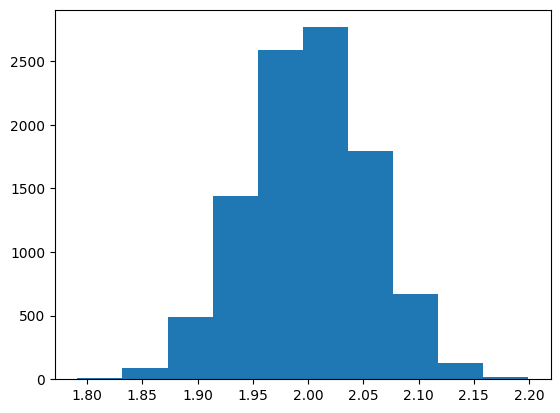

In [14]:
# Plot the sampling distribution
simulator_instance.plot_sampling_distribution()

In [15]:
# Approximate the two-sided probability of being larger than 2.1
probability = simulator_instance.find_prob(value=2.1, sided="two-sided")
print(f"Two-sided probability of the slope being larger than 2.1: {probability}")

Two-sided probability of the slope being larger than 2.1: 0.0704


In [16]:
# Print out the value of the simulated slopes using the attribute
print("Simulated slopes (first 10 values):\n", simulator_instance.beta_array[:10, 1])

Simulated slopes (first 10 values):
 [2.0239168  1.99560551 2.04249093 1.96489641 2.01114235 1.98626121
 2.03443803 2.08981268 2.01691868 1.91179937]
